In [1]:
"""
Thresholding y Binarización
Este notebook introduce el thresholding como la forma más simple de segmentación de imágenes.
Partimos de imágenes en escala de grises y las convertimos en máscaras binarias separando el primer plano del fondo mediante valores de intensidad. 
Exploramos el thresholding manual, la interpretación basada en histogramas, el método de Otsu y el efecto del ruido en la calidad de la segmentación.
Objetivos de aprendizaje
- Comprender qué es la thresholding
- Aplicar la thresholding manual y automática
- Interpretar la segmentación mediante histogramas de imagen
- Comprender conceptualmente el método de Otsu
- Evaluar la segmentación comparándola con datos sintéticos de referencia
- Reconocer las limitaciones de la thresholding en condiciones de ruido
Contexto de la imagen científica
La thresholding se utiliza ampliamente en la imagen científica como primer paso para:
- Separación de poros y matriz en micro-CT
- Detección de partículas
- Segmentación de fase
- Generación de máscaras binarias para análisis cuantitativo
"""

'\nThresholding y Binarización\nEste notebook introduce el thresholding como la forma más simple de segmentación de imágenes.\nPartimos de imágenes en escala de grises y las convertimos en máscaras binarias separando el primer plano del fondo mediante valores de intensidad. \nExploramos el thresholding manual, la interpretación basada en histogramas, el método de Otsu y el efecto del ruido en la calidad de la segmentación.\nObjetivos de aprendizaje\n- Comprender qué es la thresholding\n- Aplicar la thresholding manual y automática\n- Interpretar la segmentación mediante histogramas de imagen\n- Comprender conceptualmente el método de Otsu\n- Evaluar la segmentación comparándola con datos sintéticos de referencia\n- Reconocer las limitaciones de la thresholding en condiciones de ruido\nContexto de la imagen científica\nLa thresholding se utiliza ampliamente en la imagen científica como primer paso para:\n- Separación de poros y matriz en micro-CT\n- Detección de partículas\n- Segmentaci

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import os

from skimage import data, filters, util
from skimage.draw import disk, rectangle
from skimage.metrics import adapted_rand_error

In [25]:
def show_image(image, title="", cmap="gray", save_path=None):
    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    
    plt.show()


def show_histogram(image, threshold=None, title="Histogram"):
    plt.figure(figsize=(6, 4))
    plt.hist(image.ravel(), bins=256)
    if threshold is not None:
        plt.axvline(threshold, linestyle="--")
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Pixel count")
    plt.show()


def dice_score(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)
    intersection = np.logical_and(gt, pred).sum()
    denom = gt.sum() + pred.sum()
    if denom == 0:
        return 1.0
    return 2 * intersection / denom


def iou_score(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)
    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    if union == 0:
        return 1.0
    return intersection / union


def evaluate_segmentation(gt, pred):
    print(f"Dice score: {dice_score(gt, pred):.4f}")
    print(f"IoU score:  {iou_score(gt, pred):.4f}")

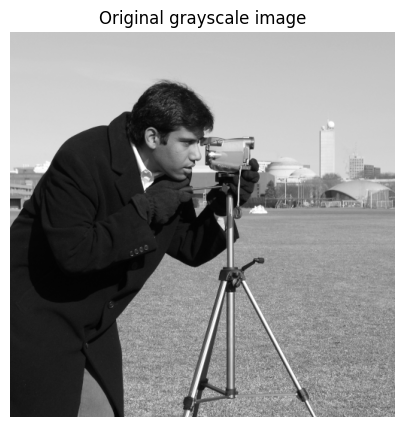

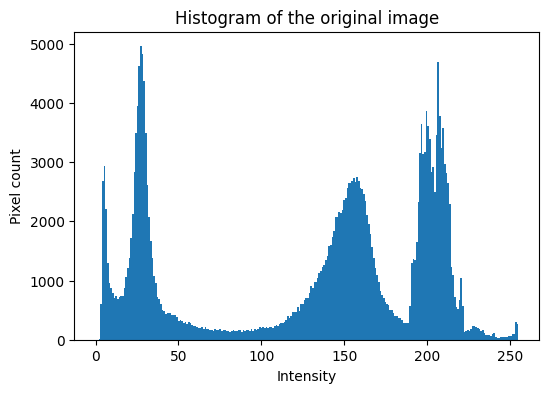

In [26]:
# Load example grayscale image
image = data.camera()

show_image(image, "Original grayscale image")
show_histogram(image, title="Histogram of the original image")

In [27]:
"""
Threshold manual
El threshold manual es elegido por el usuario, esto es buena para construir la intuicion pero tal vez no generaliza toda la imagen.
"""

'\nThreshold manual\nEl threshold manual es elegido por el usuario, esto es buena para construir la intuicion pero tal vez no generaliza toda la imagen.\n'

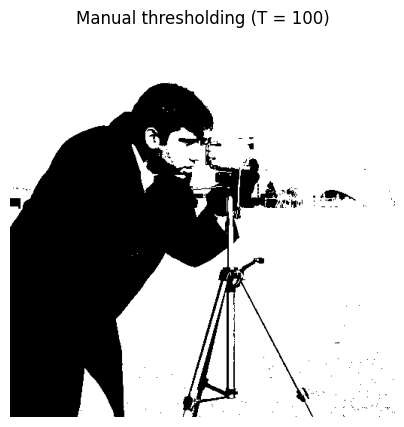

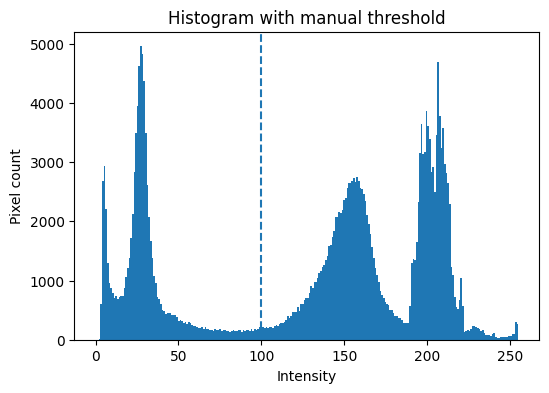

In [28]:
manual_threshold = 100
binary_manual = image > manual_threshold

show_image(binary_manual, f"Manual thresholding (T = {manual_threshold})")
show_histogram(image, threshold=manual_threshold, title="Histogram with manual threshold")

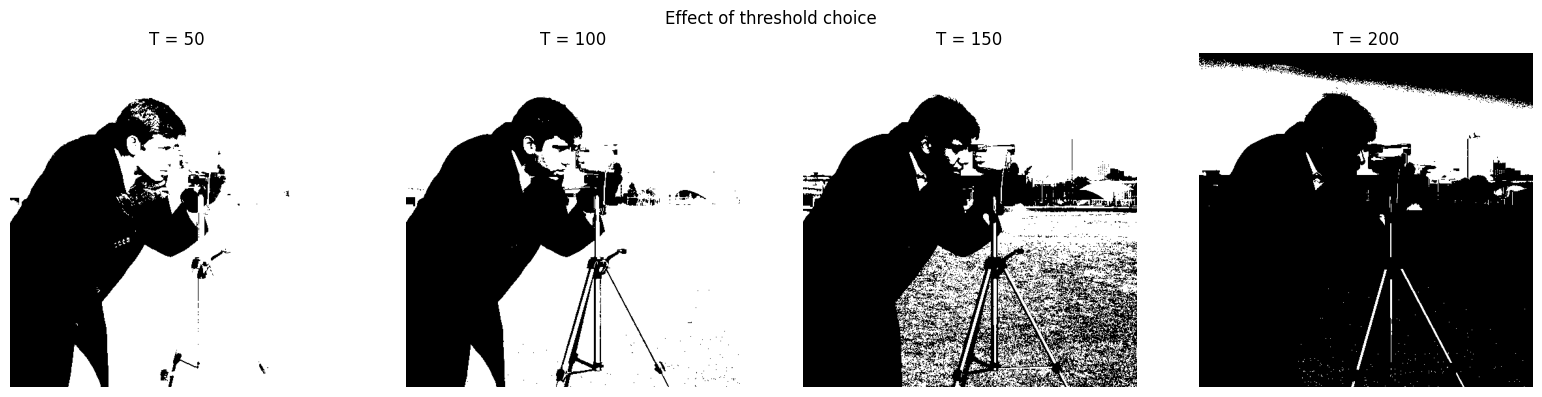

In [29]:
threshold_values = [50, 100, 150, 200]

fig, axes = plt.subplots(1, len(threshold_values), figsize=(16, 4))
for ax, t in zip(axes, threshold_values):
    ax.imshow(image > t, cmap="gray")
    ax.set_title(f"T = {t}")
    ax.axis("off")
plt.suptitle("Effect of threshold choice")
plt.tight_layout()
plt.savefig("../figures/figures_threshold_binary/manual_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

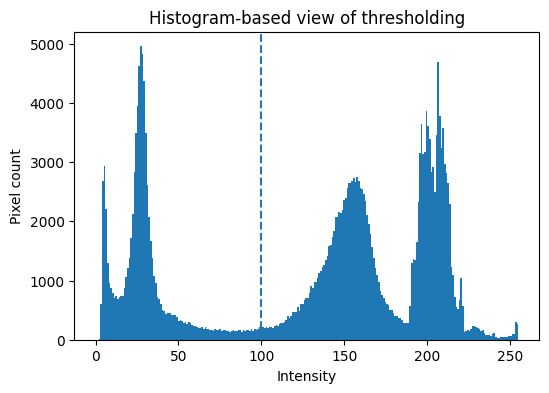

In [30]:
show_histogram(image, threshold=manual_threshold, title="Histogram-based view of thresholding")

In [31]:
"""
Método de Otsu
El método de Otsu selecciona automáticamente un umbral global maximizando la separación entre dos clases de intensidad.
Funciona mejor cuando el histograma es aproximadamente bimodal y las intensidades del primer plano y del fondo están razonablemente separadas.
"""

'\nMétodo de Otsu\nEl método de Otsu selecciona automáticamente un umbral global maximizando la separación entre dos clases de intensidad.\nFunciona mejor cuando el histograma es aproximadamente bimodal y las intensidades del primer plano y del fondo están razonablemente separadas.\n'

Otsu threshold: 102.00


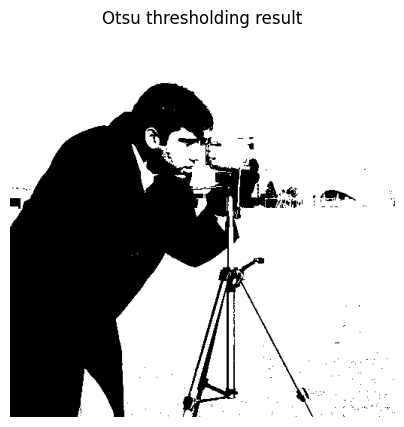

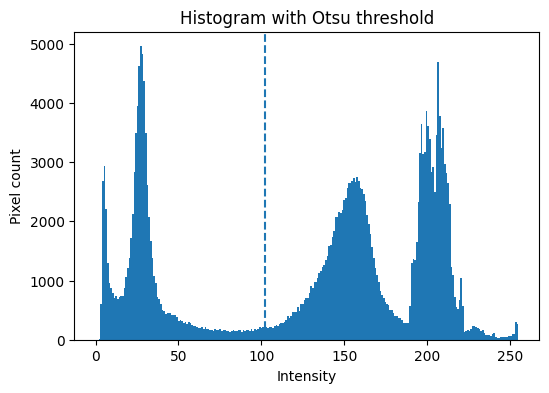

In [32]:
otsu_threshold = filters.threshold_otsu(image)
binary_otsu = image > otsu_threshold

print(f"Otsu threshold: {otsu_threshold:.2f}")

show_image(binary_otsu, "Otsu thresholding result")
show_histogram(image, threshold=otsu_threshold, title="Histogram with Otsu threshold")

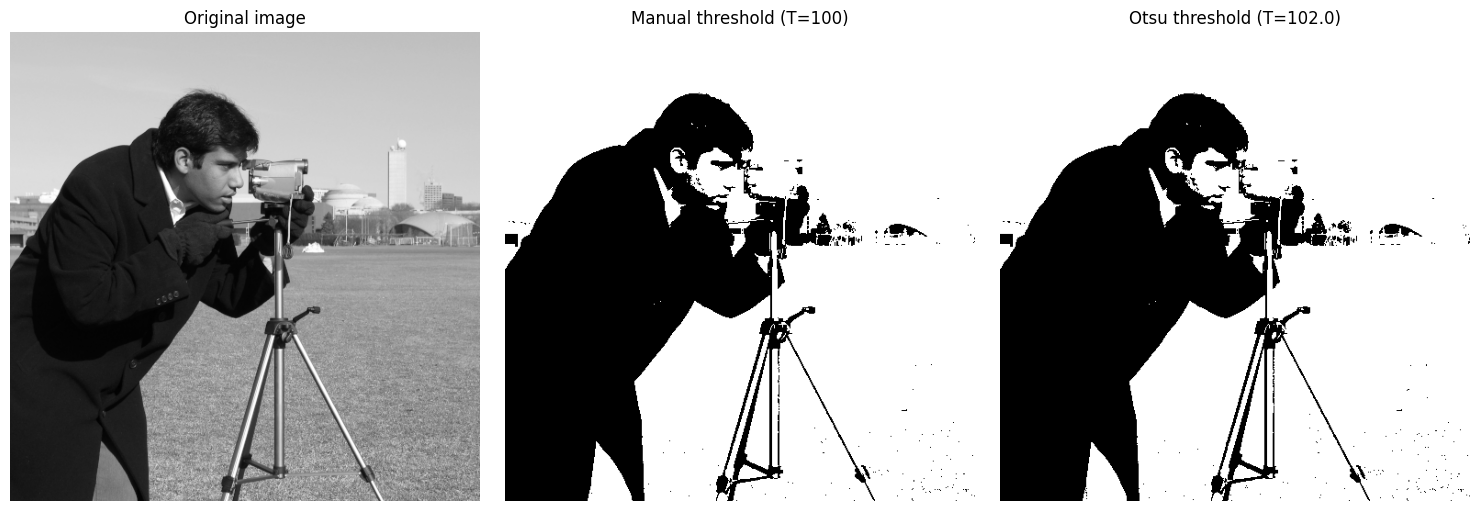

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(binary_manual, cmap="gray")
axes[1].set_title(f"Manual threshold (T={manual_threshold})")
axes[1].axis("off")

axes[2].imshow(binary_otsu, cmap="gray")
axes[2].set_title(f"Otsu threshold (T={otsu_threshold:.1f})")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("../figures/figures_threshold_binary/otsu_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
"""
Ejemplo sintético con datos reales conocidos
Para evaluar cuantitativamente el umbral, creamos una imagen sintética cuya máscara de segmentación real es conocida.
Esto nos permite comparar las predicciones con los datos reales utilizando métricas de segmentación como el coeficiente de Dice y la intersección sobre unión (IoU).
"""

'\nEjemplo sintético con datos reales conocidos\nPara evaluar cuantitativamente el umbral, creamos una imagen sintética cuya máscara de segmentación real es conocida.\nEsto nos permite comparar las predicciones con los datos reales utilizando métricas de segmentación como el coeficiente de Dice y la intersección sobre unión (IoU).\n'

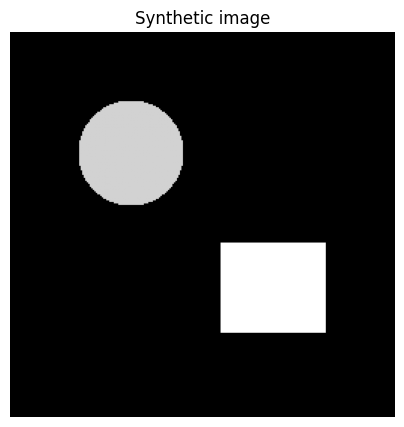

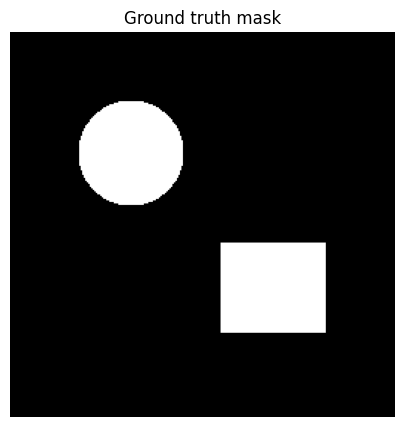

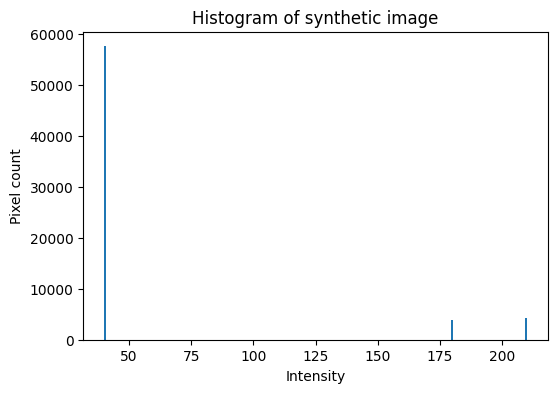

In [35]:
synthetic = np.full((256, 256), 40, dtype=np.uint8)
ground_truth = np.zeros((256, 256), dtype=bool)

rr, cc = disk((80, 80), 35)
synthetic[rr, cc] = 180
ground_truth[rr, cc] = True

start = (140, 140)
extent = (60, 70)
rr, cc = rectangle(start=start, extent=extent, shape=synthetic.shape)
synthetic[rr, cc] = 210
ground_truth[rr, cc] = True

show_image(synthetic, "Synthetic image")
show_image(ground_truth, "Ground truth mask")
show_histogram(synthetic, title="Histogram of synthetic image")

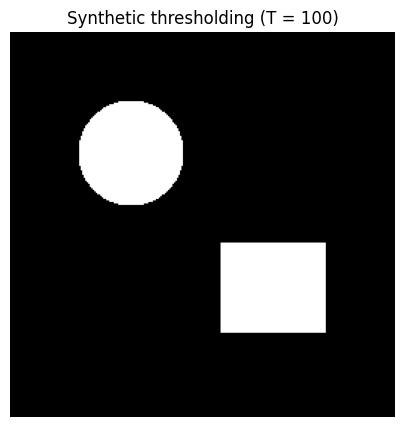

Dice score: 1.0000
IoU score:  1.0000


In [36]:
synthetic_threshold = 100
synthetic_pred = synthetic > synthetic_threshold

show_image(synthetic_pred, f"Synthetic thresholding (T = {synthetic_threshold})")
evaluate_segmentation(ground_truth, synthetic_pred)

Otsu threshold on synthetic image: 40.00


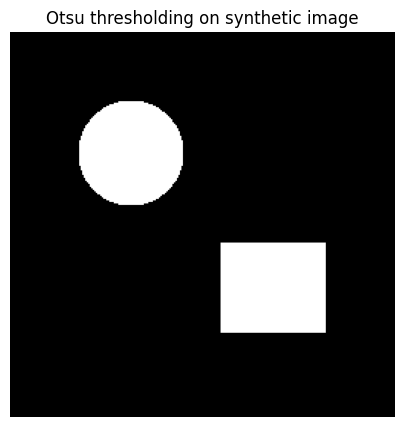

Dice score: 1.0000
IoU score:  1.0000


In [37]:
synthetic_otsu = filters.threshold_otsu(synthetic)
synthetic_pred_otsu = synthetic > synthetic_otsu

print(f"Otsu threshold on synthetic image: {synthetic_otsu:.2f}")
show_image(synthetic_pred_otsu, "Otsu thresholding on synthetic image")
evaluate_segmentation(ground_truth, synthetic_pred_otsu)

In [38]:
"""
Thresholding bajo ruido
Los datos de imágenes reales suelen degradarse por ruido, desenfoque, dispersión, contraste limitado o inhomogeneidad de la iluminación.
Aquí simulamos ruido para mostrar cómo cambia el rendimiento de la umbralización en condiciones menos ideales (IoU).
"""

'\nThresholding bajo ruido\nLos datos de imágenes reales suelen degradarse por ruido, desenfoque, dispersión, contraste limitado o inhomogeneidad de la iluminación.\nAquí simulamos ruido para mostrar cómo cambia el rendimiento de la umbralización en condiciones menos ideales (IoU).\n'

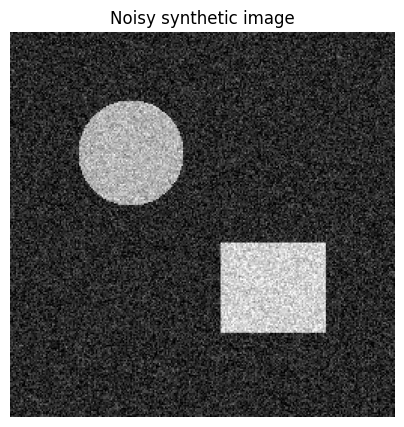

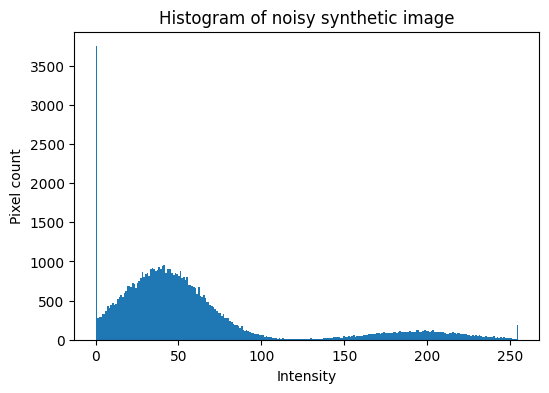

In [39]:
noisy_synthetic = util.random_noise(synthetic, mode="gaussian", var=0.01)
noisy_synthetic = (255 * noisy_synthetic).astype(np.uint8)

show_image(noisy_synthetic, "Noisy synthetic image", save_path="../figures/figures_threshold_binary/synthetic_imagen_noise.png")
show_histogram(noisy_synthetic, title="Histogram of noisy synthetic image")